In [1]:
# Setup: only math/array/plotting utilities (no model libraries, no activation utilities)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Environment ready.')

Environment ready.


# Activation Functions in a Single-Layer Network (Manual Implementation)

This notebook teaches activations by implementing everything manually with NumPy math only.

Rules followed in this notebook:
- no model libraries (no sklearn models, no torch, no tensorflow)
- no built-in activation helpers
- no reusable `def` model functions
- single-layer networks only
- manual forward pass, loss, gradients, and updates

We cover:
1. Binary Step (perceptron-style inference)
2. Linear (identity) for regression
3. Sigmoid for binary classification
4. Tanh for zero-centered binary classification
5. ReLU and Leaky ReLU for regression
6. Softmax for multiclass classification

Binary dataset: (10, 2) (10, 1)
Regression dataset: (40, 1) (40, 1)
Multiclass dataset: (12, 2) (12, 3)


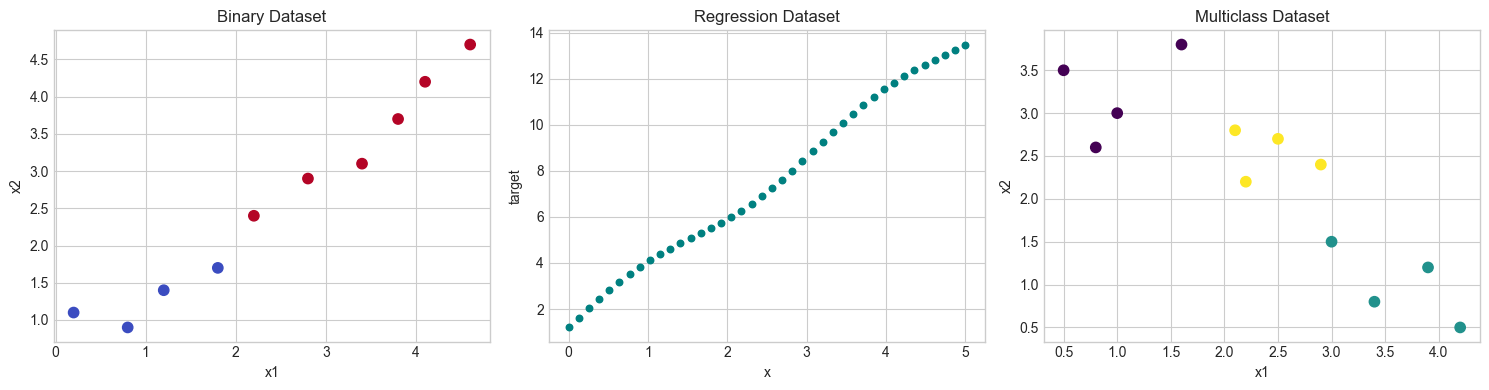

In [2]:
# Create manual sample datasets for different activation behavior

# 1) Binary classification dataset (linearly separable)
X_bin = np.array([
    [0.2, 1.1],
    [0.8, 0.9],
    [1.2, 1.4],
    [1.8, 1.7],
    [2.2, 2.4],
    [2.8, 2.9],
    [3.4, 3.1],
    [3.8, 3.7],
    [4.1, 4.2],
    [4.6, 4.7],
])
y_bin = np.array([[0], [0], [0], [0], [1], [1], [1], [1], [1], [1]], dtype=float)

# 2) Regression dataset (positive target)
x_reg = np.linspace(0, 5, 40).reshape(-1, 1)
y_reg = 2.5 * x_reg + 1.2 + 0.4 * np.sin(2.0 * x_reg)

# 3) Multiclass dataset (3 classes in 2D)
X_multi = np.array([
    [0.5, 3.5], [1.0, 3.0], [1.6, 3.8], [0.8, 2.6],
    [3.4, 0.8], [3.9, 1.2], [4.2, 0.5], [3.0, 1.5],
    [2.2, 2.2], [2.5, 2.7], [2.9, 2.4], [2.1, 2.8],
])
y_multi_idx = np.array([0,0,0,0, 1,1,1,1, 2,2,2,2])
y_multi = np.eye(3)[y_multi_idx]

print('Binary dataset:', X_bin.shape, y_bin.shape)
print('Regression dataset:', x_reg.shape, y_reg.shape)
print('Multiclass dataset:', X_multi.shape, y_multi.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_bin[:, 0], X_bin[:, 1], c=y_bin.ravel(), cmap='coolwarm', s=55)
axes[0].set_title('Binary Dataset')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

axes[1].scatter(x_reg[:, 0], y_reg[:, 0], color='teal', s=22)
axes[1].set_title('Regression Dataset')
axes[1].set_xlabel('x')
axes[1].set_ylabel('target')

axes[2].scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi_idx, cmap='viridis', s=55)
axes[2].set_title('Multiclass Dataset')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')

plt.tight_layout()
plt.show()

## 1) Binary Step Activation (Perceptron-Style)

Activation equation:
$$
\hat{y} = \begin{cases}
1 & z \ge 0 \\
0 & z < 0
\end{cases}, \quad z = XW + b
$$

Key impact:
- good for hard threshold decisions
- not differentiable, so gradient descent is not suitable
- mostly historical for learning and logic-style rules

In [5]:
# Manual perceptron-like update with binary step (no differentiable gradient)

X = X_bin.copy()
y = y_bin.copy()

W_step = np.zeros((2, 1))
b_step = 0.0
lr_step = 0.1
epochs_step = 20

step_errors = []

for epoch in range(epochs_step):
    epoch_error = 0
    for i in range(X.shape[0]):
        z = X[i:i+1] @ W_step + b_step
        pred = (z >= 0).astype(float)
        err = y[i:i+1] - pred
        W_step += lr_step * X[i:i+1].T * err
        b_step += float(lr_step * err)
        epoch_error += abs(float(err))
    step_errors.append(epoch_error)

z_all = X @ W_step + b_step
pred_all = (z_all >= 0).astype(float)
acc_step = np.mean(pred_all == y)

print('Binary Step final W:', W_step.ravel())
print('Binary Step final b:', b_step)
print('Binary Step train accuracy:', round(float(acc_step), 4))

plt.figure(figsize=(6, 3))
plt.plot(range(1, epochs_step + 1), step_errors, marker='o')
plt.title('Binary Step: Epoch Error Count')
plt.xlabel('Epoch')
plt.ylabel('Total Misclassifications')
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

## 2) Sigmoid Activation (Best for Binary Output Layer)

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

- Output range: $[0,1]$
- Great for binary probability output
- Can saturate for large $|z|$ and slow learning

Sigmoid final accuracy: 0.9


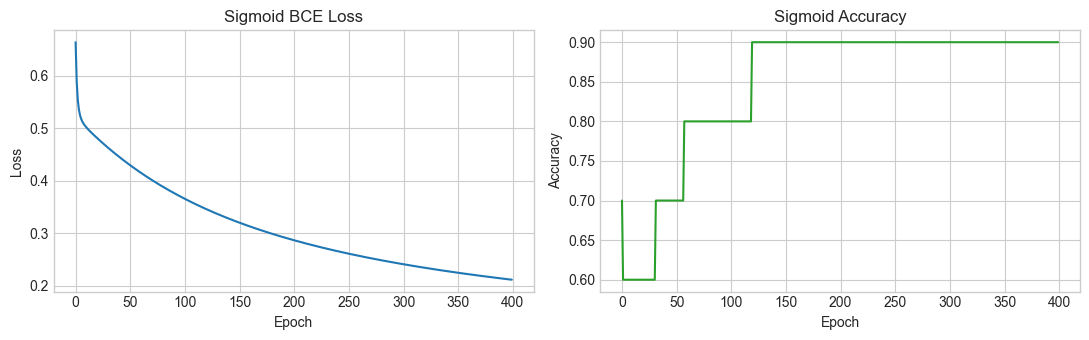

In [6]:
# Manual sigmoid training (single-layer, binary cross entropy)

X = X_bin.copy()
y = y_bin.copy()

W_sig = np.random.randn(2, 1) * 0.1
b_sig = 0.0
lr_sig = 0.08
epochs_sig = 400

loss_sig_hist = []
acc_sig_hist = []

for epoch in range(epochs_sig):
    z = X @ W_sig + b_sig
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

    eps = 1e-9
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    dz = p - y
    dW = (X.T @ dz) / X.shape[0]
    db = np.mean(dz)

    W_sig -= lr_sig * dW
    b_sig -= lr_sig * db

    pred = (p >= 0.5).astype(float)
    acc = np.mean(pred == y)

    loss_sig_hist.append(float(loss))
    acc_sig_hist.append(float(acc))

print('Sigmoid final accuracy:', round(acc_sig_hist[-1], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(loss_sig_hist, color='tab:blue')
axes[0].set_title('Sigmoid BCE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(acc_sig_hist, color='tab:green')
axes[1].set_title('Sigmoid Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 3) Tanh Activation (Zero-Centered Alternative)

$$
\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}
$$

- Output range: $[-1,1]$
- Often trains faster than sigmoid in hidden layers due to zero-centered outputs
- Still saturates at large $|z|$

Tanh final accuracy: 1.0


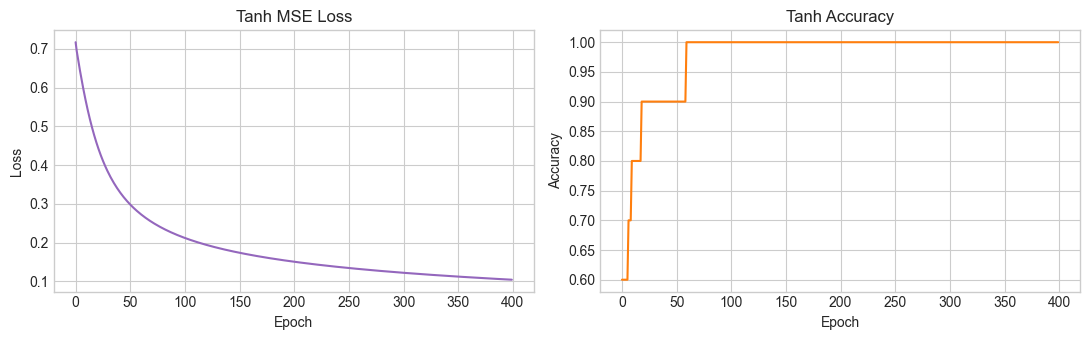

In [7]:
# Manual tanh training for binary classification (with labels mapped to -1/+1)

X = X_bin.copy()
y01 = y_bin.copy()
y_tanh = 2 * y01 - 1

W_tanh = np.random.randn(2, 1) * 0.1
b_tanh = 0.0
lr_tanh = 0.05
epochs_tanh = 400

loss_tanh_hist = []
acc_tanh_hist = []

for epoch in range(epochs_tanh):
    z = X @ W_tanh + b_tanh
    a = np.tanh(z)
    loss = np.mean((a - y_tanh) ** 2)

    da = 2 * (a - y_tanh) / X.shape[0]
    dz = da * (1 - a**2)
    dW = X.T @ dz
    db = np.sum(dz)

    W_tanh -= lr_tanh * dW
    b_tanh -= lr_tanh * db

    pred = (a >= 0).astype(float)
    acc = np.mean(pred == y01)

    loss_tanh_hist.append(float(loss))
    acc_tanh_hist.append(float(acc))

print('Tanh final accuracy:', round(acc_tanh_hist[-1], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(loss_tanh_hist, color='tab:purple')
axes[0].set_title('Tanh MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(acc_tanh_hist, color='tab:orange')
axes[1].set_title('Tanh Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 4) Linear, ReLU, and Leaky ReLU (Regression Output)

### Linear (Identity)
$$
a=z
$$

### ReLU
$$
a=\max(0,z)
$$

### Leaky ReLU
$$
a=\max(\alpha z, z), \; \alpha=0.01
$$

Use case intuition:
- Linear: best output activation for unrestricted regression
- ReLU: useful in hidden layers, but can die for negative region
- Leaky ReLU: helps reduce dead-neuron issue by keeping small negative slope

Linear final MSE: 0.06991


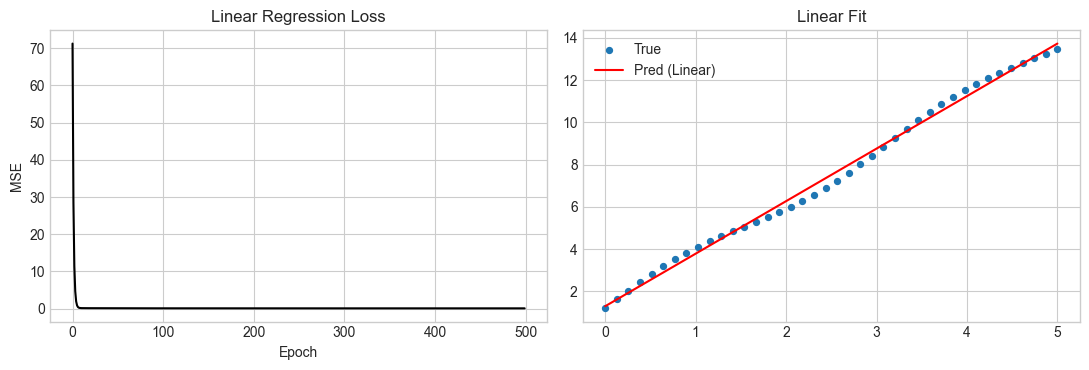

In [8]:
# Linear activation for regression (best baseline for unrestricted output)

X = x_reg.copy()
y = y_reg.copy()

W_lin = np.random.randn(1, 1) * 0.1
b_lin = 0.0
lr_lin = 0.02
epochs_lin = 500

lin_loss_hist = []

for epoch in range(epochs_lin):
    z = X @ W_lin + b_lin
    a = z
    loss = np.mean((a - y) ** 2)

    dz = 2 * (a - y) / X.shape[0]
    dW = X.T @ dz
    db = np.sum(dz)

    W_lin -= lr_lin * dW
    b_lin -= lr_lin * db

    lin_loss_hist.append(float(loss))

pred_lin = X @ W_lin + b_lin
mse_lin = np.mean((pred_lin - y) ** 2)
print('Linear final MSE:', round(float(mse_lin), 5))

plt.figure(figsize=(11, 3.8))
plt.subplot(1, 2, 1)
plt.plot(lin_loss_hist, color='black')
plt.title('Linear Regression Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], y[:, 0], s=18, label='True')
plt.plot(X[:, 0], pred_lin[:, 0], color='red', label='Pred (Linear)')
plt.title('Linear Fit')
plt.legend()
plt.tight_layout()
plt.show()

ReLU final MSE: 70.12311
Leaky ReLU final MSE: 0.07657


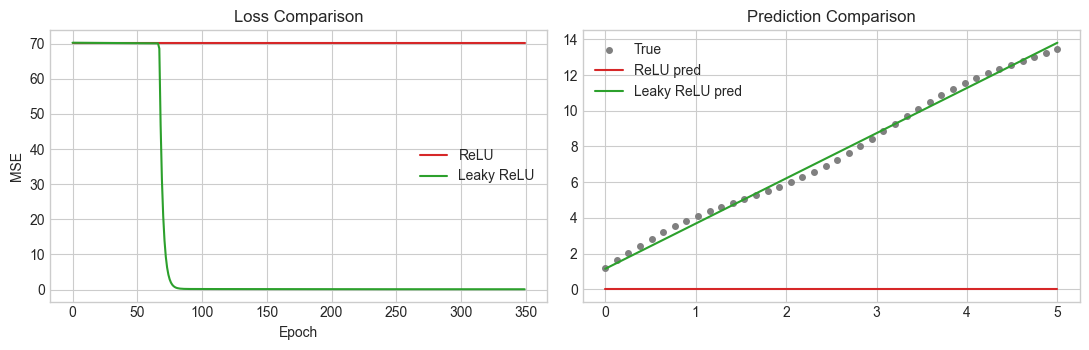

In [9]:
# ReLU vs Leaky ReLU on same regression data

X = x_reg.copy()
y = y_reg.copy()

# ReLU model
W_relu = np.array([[-0.3]])  # deliberately negative start to show dying tendency
b_relu = -0.2
lr_relu = 0.01
epochs_relu = 350
relu_loss_hist = []

for epoch in range(epochs_relu):
    z = X @ W_relu + b_relu
    a = np.maximum(0, z)
    loss = np.mean((a - y) ** 2)

    da = 2 * (a - y) / X.shape[0]
    dz = da * (z > 0).astype(float)
    dW = X.T @ dz
    db = np.sum(dz)

    W_relu -= lr_relu * dW
    b_relu -= lr_relu * db

    relu_loss_hist.append(float(loss))

pred_relu = np.maximum(0, X @ W_relu + b_relu)
mse_relu = np.mean((pred_relu - y) ** 2)

# Leaky ReLU model
alpha = 0.01
W_lrelu = np.array([[-0.3]])
b_lrelu = -0.2
lr_lrelu = 0.01
epochs_lrelu = 350
lrelu_loss_hist = []

for epoch in range(epochs_lrelu):
    z = X @ W_lrelu + b_lrelu
    a = np.where(z > 0, z, alpha * z)
    loss = np.mean((a - y) ** 2)

    da = 2 * (a - y) / X.shape[0]
    dz = da * np.where(z > 0, 1.0, alpha)
    dW = X.T @ dz
    db = np.sum(dz)

    W_lrelu -= lr_lrelu * dW
    b_lrelu -= lr_lrelu * db

    lrelu_loss_hist.append(float(loss))

pred_lrelu = np.where(X @ W_lrelu + b_lrelu > 0, X @ W_lrelu + b_lrelu, alpha * (X @ W_lrelu + b_lrelu))
mse_lrelu = np.mean((pred_lrelu - y) ** 2)

print('ReLU final MSE:', round(float(mse_relu), 5))
print('Leaky ReLU final MSE:', round(float(mse_lrelu), 5))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(relu_loss_hist, label='ReLU', color='tab:red')
axes[0].plot(lrelu_loss_hist, label='Leaky ReLU', color='tab:green')
axes[0].set_title('Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].scatter(X[:, 0], y[:, 0], s=16, color='gray', label='True')
axes[1].plot(X[:, 0], pred_relu[:, 0], color='tab:red', label='ReLU pred')
axes[1].plot(X[:, 0], pred_lrelu[:, 0], color='tab:green', label='Leaky ReLU pred')
axes[1].set_title('Prediction Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5) Softmax Activation (Multiclass Output)

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

Best use case:
- output layer for multiclass classification (mutually exclusive classes)

Softmax final accuracy: 1.0


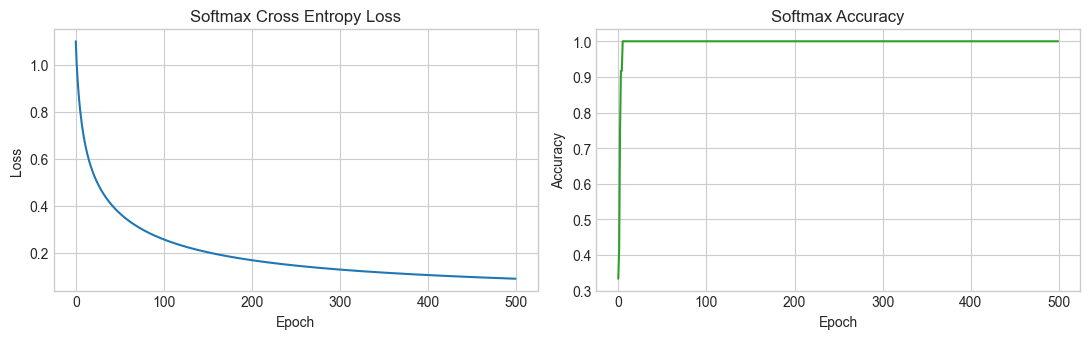

In [10]:
# Manual softmax multiclass training (single-layer + cross entropy)

X = X_multi.copy()
y = y_multi.copy()
y_idx = y_multi_idx.copy()

W_soft = np.random.randn(2, 3) * 0.1
b_soft = np.zeros((1, 3))
lr_soft = 0.12
epochs_soft = 500

soft_loss_hist = []
soft_acc_hist = []

for epoch in range(epochs_soft):
    logits = X @ W_soft + b_soft
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(logits)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    eps = 1e-9
    loss = -np.mean(np.sum(y * np.log(probs + eps), axis=1))

    dlogits = (probs - y) / X.shape[0]
    dW = X.T @ dlogits
    db = np.sum(dlogits, axis=0, keepdims=True)

    W_soft -= lr_soft * dW
    b_soft -= lr_soft * db

    pred_idx = np.argmax(probs, axis=1)
    acc = np.mean(pred_idx == y_idx)

    soft_loss_hist.append(float(loss))
    soft_acc_hist.append(float(acc))

print('Softmax final accuracy:', round(soft_acc_hist[-1], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(soft_loss_hist, color='tab:blue')
axes[0].set_title('Softmax Cross Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(soft_acc_hist, color='tab:green')
axes[1].set_title('Softmax Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

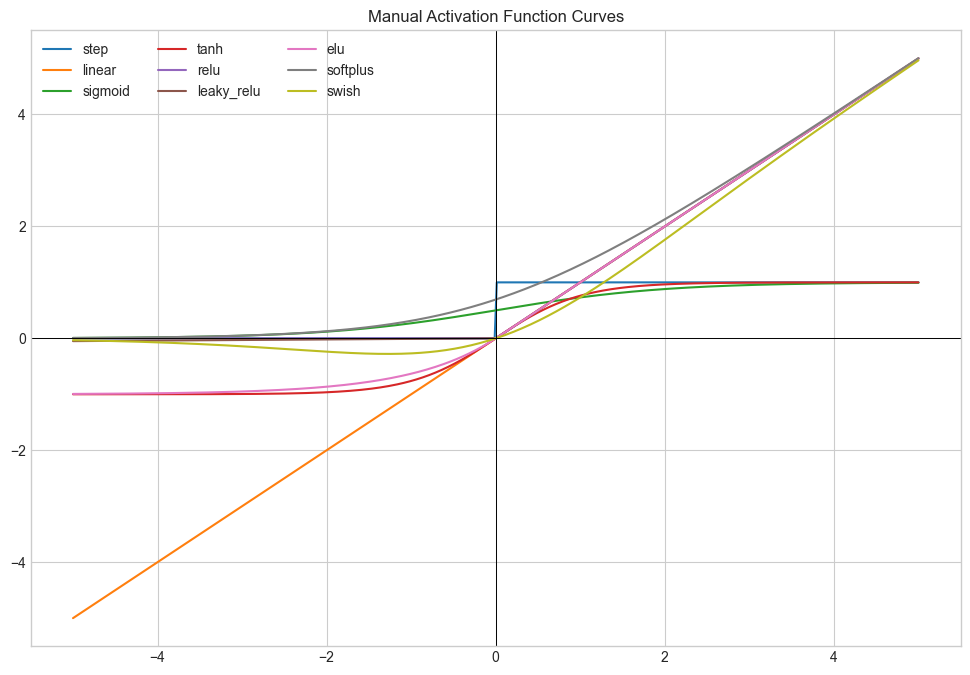

In [11]:
# Manual formulas for additional common activations (forward behavior only)

x = np.linspace(-5, 5, 400)

y_step = (x >= 0).astype(float)
y_linear = x
y_sigmoid = 1 / (1 + np.exp(-x))
y_tanh = np.tanh(x)
y_relu = np.maximum(0, x)
y_lrelu = np.where(x > 0, x, 0.01 * x)
y_elu = np.where(x > 0, x, 1.0 * (np.exp(x) - 1))
y_softplus = np.log1p(np.exp(x))
y_swish = x * (1 / (1 + np.exp(-x)))

plt.figure(figsize=(12, 8))
plt.plot(x, y_step, label='step')
plt.plot(x, y_linear, label='linear')
plt.plot(x, y_sigmoid, label='sigmoid')
plt.plot(x, y_tanh, label='tanh')
plt.plot(x, y_relu, label='relu')
plt.plot(x, y_lrelu, label='leaky_relu')
plt.plot(x, y_elu, label='elu')
plt.plot(x, y_softplus, label='softplus')
plt.plot(x, y_swish, label='swish')
plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.title('Manual Activation Function Curves')
plt.legend(loc='upper left', ncol=3)
plt.show()

## Practical “Best Use” Guide

- Binary Step: only for hard-threshold logic/perceptron demonstrations; not gradient-based learning.
- Linear: output layer for regression when values are unrestricted.
- Sigmoid: output layer for binary classification probabilities.
- Tanh: hidden layers when zero-centered activations help, but watch saturation.
- ReLU: default hidden activation in many deep nets due to simplicity and sparse activation.
- Leaky ReLU: better than ReLU when dead neurons appear.
- ELU / Softplus / Swish: smoother alternatives that can improve optimization in some tasks.
- Softmax: output layer for multiclass classification with one class per sample.

### Final metric snapshot from this notebook run

You can run this cell after running all training cells to get a compact report:

```python
summary = pd.DataFrame([
    {'activation': 'binary_step', 'task': 'binary_classification', 'metric': float(acc_step)},
    {'activation': 'sigmoid', 'task': 'binary_classification', 'metric': float(acc_sig_hist[-1])},
    {'activation': 'tanh', 'task': 'binary_classification', 'metric': float(acc_tanh_hist[-1])},
    {'activation': 'linear', 'task': 'regression_mse', 'metric': float(mse_lin)},
    {'activation': 'relu', 'task': 'regression_mse', 'metric': float(mse_relu)},
    {'activation': 'leaky_relu', 'task': 'regression_mse', 'metric': float(mse_lrelu)},
    {'activation': 'softmax', 'task': 'multiclass_accuracy', 'metric': float(soft_acc_hist[-1])},
])
display(summary)
```